In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

## Part (b)

**Early 40 years — month-end data only.** `monthly_early` holds one row per calendar month: the **last trading day** and its **Close**. There are no observed daily levels in that window for the case study.

**Simulation anchoring (default in `partb_sim` / `spx_trading_day_buyhold`):** each bridged month uses exactly **two** observed anchors: the **previous month-end Close** (start of the segment) and the **current month-end Close** (end). GARCH draws fill the trading days in between; the log bridge forces the path to hit that month-end. **Drawdowns, pooled rolling returns, histograms, and tail percentiles** are computed **after** building full paths this way.

**Optional:** `use_first_trading_day_close_anchor=True` also pins the first intra-month day to `daily_full` (off by default so we do not treat that day as observed in the low-frequency panel).


In [2]:

from partb import build_part_b_dataset, build_part_b_split, split_summary

df = build_part_b_dataset()
split_summary(df)

import pandas as pd
from partb import build_part_b_split, load_monthly_early_csv, load_spx_daily
from partb_sim import bridge_interval_from_monthly_early

daily_full = load_spx_daily()
monthly_early, daily_recent, combined = build_part_b_split()

In [3]:
monthly_early.to_csv("monthly_early.csv")

In [4]:
daily_recent.head()

,year_month,Date,Open,High,Low,Close,Volume,granularity
0,NaN,2016-03-01,1937.09,1978.35,1937.09,1978.35,2677638889,daily
1,NaN,2016-03-02,1976.60,1986.51,1968.80,1986.45,2592561111,daily
2,NaN,2016-03-03,1985.60,1993.69,1977.37,1993.40,2823166667,daily
3,NaN,2016-03-04,1994.01,2009.13,1986.77,1999.99,3361072222,daily
4,NaN,2016-03-07,1996.11,2006.12,1989.38,2001.76,2760100000,daily


In [5]:
# t-GARCH on daily_recent: needs `arch` in this notebook's Python env.
# In terminal (from project folder): .venv/bin/pip install arch
# In Jupyter: pick kernel "Python (.venv)" or similar so imports find `partb`.

from partb import (
    compute_log_returns,
    fit_t_garch_on_daily_recent,
    compare_garch_orders,
)

log_r = compute_log_returns(daily_recent)
log_r.head(), len(log_r)


(2016-03-02    0.004086
 2016-03-03    0.003493
 2016-03-04    0.003300
 2016-03-07    0.000885
 2016-03-08   -0.011304
 Name: log_return, dtype: float64,
 2513)

## 1. If you have multiple approaches at least one of them should be the construction/simulation of daily data. (DAILY CONSTRUCTION ESTIMATION)

In [6]:
# Fit GARCH(1,1)-t (default); use garch.fit for simulation later.
garch = fit_t_garch_on_daily_recent(daily_recent)
garch.params, garch.scale


({'mu': 0.0979265573355916,
  'omega': 0.020558961909627395,
  'alpha[1]': 0.16719792930117114,
  'beta[1]': 0.8302108794924186,
  'nu': 5.016668668801989},
 100.0)

In [7]:
# Optional: (1,1) vs (2,1) vs (1,2) by BIC + Ljung–Box on z^2 for chosen model
sel = compare_garch_orders(daily_recent)
sel["criteria_table"]


,p,q,loglikelihood,aic,bic,converged
0,1,1,-3106.345951,6222.691902,6251.838064,True
1,2,1,-3106.245009,6224.490018,6259.465413,True
2,1,2,-3106.345951,6224.691901,6259.667296,True


In [8]:
sel["model_selection_note"], sel["chosen_order"]
sel["ljung_box_sq_std_residuals"]


,lb_stat,lb_pvalue
1,0.769430,0.380393
2,1.082749,0.581948
3,1.126661,0.770642
4,3.817151,0.431317
5,4.464331,0.484670
6,4.920436,0.554058
7,7.127586,0.415718
8,8.442577,0.391473
9,10.436926,0.316284
10,11.067224,0.352305


In [9]:
# Bridge interval for a *target* calendar month = year_month row (end) + previous row (start).
# March 1996 → 1996-02 month-end Close → 1996-03 month-end Close (matches monthly_early.csv).
import pandas as pd
from partb import build_part_b_split, load_monthly_early_csv, load_spx_daily
from partb_sim import bridge_interval_from_monthly_early

daily_full = load_spx_daily()
try:
    monthly_early
except NameError:
    monthly_early, _, _ = build_part_b_split()

bridge_mar_1996 = bridge_interval_from_monthly_early(
    monthly_early, 1996, 3, daily_full=daily_full
)
pd.DataFrame([{k: bridge_mar_1996[k] for k in (
    "target_year_month",
    "previous_year_month",
    "monthly_early_iloc_start",
    "monthly_early_iloc_end",
    "date_start",
    "date_end",
    "date_first_trading",
    "close_first_trading",
    "close_start",
    "close_end",
)}])

me_csv = load_monthly_early_csv()
bi_csv = bridge_interval_from_monthly_early(me_csv, 1996, 3, daily_full=daily_full)
#assert bi_csv["close_start"] == bridge_mar_1996["close_start"] == 640.43
#assert bi_csv["close_end"] == bridge_mar_1996["close_end"] == 645.5

In [10]:
# PARTB_2: bridged daily paths + drawdown Monte Carlo (see partb_sim.py)
from partb import load_spx_daily
from partb_sim import partb2_monte_carlo, partb2_month_table

daily_full = load_spx_daily()
month_tbl = partb2_month_table(monthly_early, daily_full)
month_tbl.head()


,date_start,date_end,close_start,close_end,R_month_log,n_days,date_first_trading,close_first_trading
0,1976-03-31,1976-04-30,102.77,101.64,-0.011056,21,1976-04-01,102.24
1,1976-04-30,1976-05-28,101.64,100.18,-0.014469,20,1976-05-03,100.92
2,1976-05-28,1976-06-30,100.18,104.28,0.040111,22,1976-06-01,99.85
3,1976-06-30,1976-07-30,104.28,103.44,-0.008088,21,1976-07-01,103.59
4,1976-07-30,1976-08-31,103.44,102.91,-0.005137,22,1976-08-02,103.19


## REFERENCE FROM PART a TO TEST WHETHER THE CODE MAKES SENSE OR NOT 

In [12]:
### rolling buyhold


=== 1-month horizon ===
Observations: 12603
  Entire histogram (all rolling returns) (n=12603):
    mean=0.008030  median=0.011533  skew=-0.738827  kurtosis(excess)=4.497664
Left-tail return quantiles (worst→best; ~99% / 95% / 90% loss levels):
  p1:  -0.1160 (-11.60%)  loss_mag: 0.1160
  p5:  -0.0651 (-6.51%)  loss_mag: 0.0651
  p10: -0.0437 (-4.37%)  loss_mag: 0.0437
Right-tail return quantiles (~90% / 95% / 99% gain levels):
  p90: 0.0553 (+5.53%)  gain_mag: 0.0553
  p95: 0.0711 (+7.11%)  gain_mag: 0.0711
  p99: 0.1135 (+11.35%)  gain_mag: 0.1135
Best / worst single-period return:
  Worst: -0.3167  Best: 0.2661

=== 3-month horizon ===
Observations: 12603
  Entire histogram (all rolling returns) (n=12603):
    mean=0.024117  median=0.029003  skew=-0.541327  kurtosis(excess)=2.688787
Left-tail return quantiles (worst→best; ~99% / 95% / 90% loss levels):
  p1:  -0.2117 (-21.17%)  loss_mag: 0.2117
  p5:  -0.1020 (-10.20%)  loss_mag: 0.1020
  p10: -0.0648 (-6.48%)  loss_mag: 0.0648
Rig

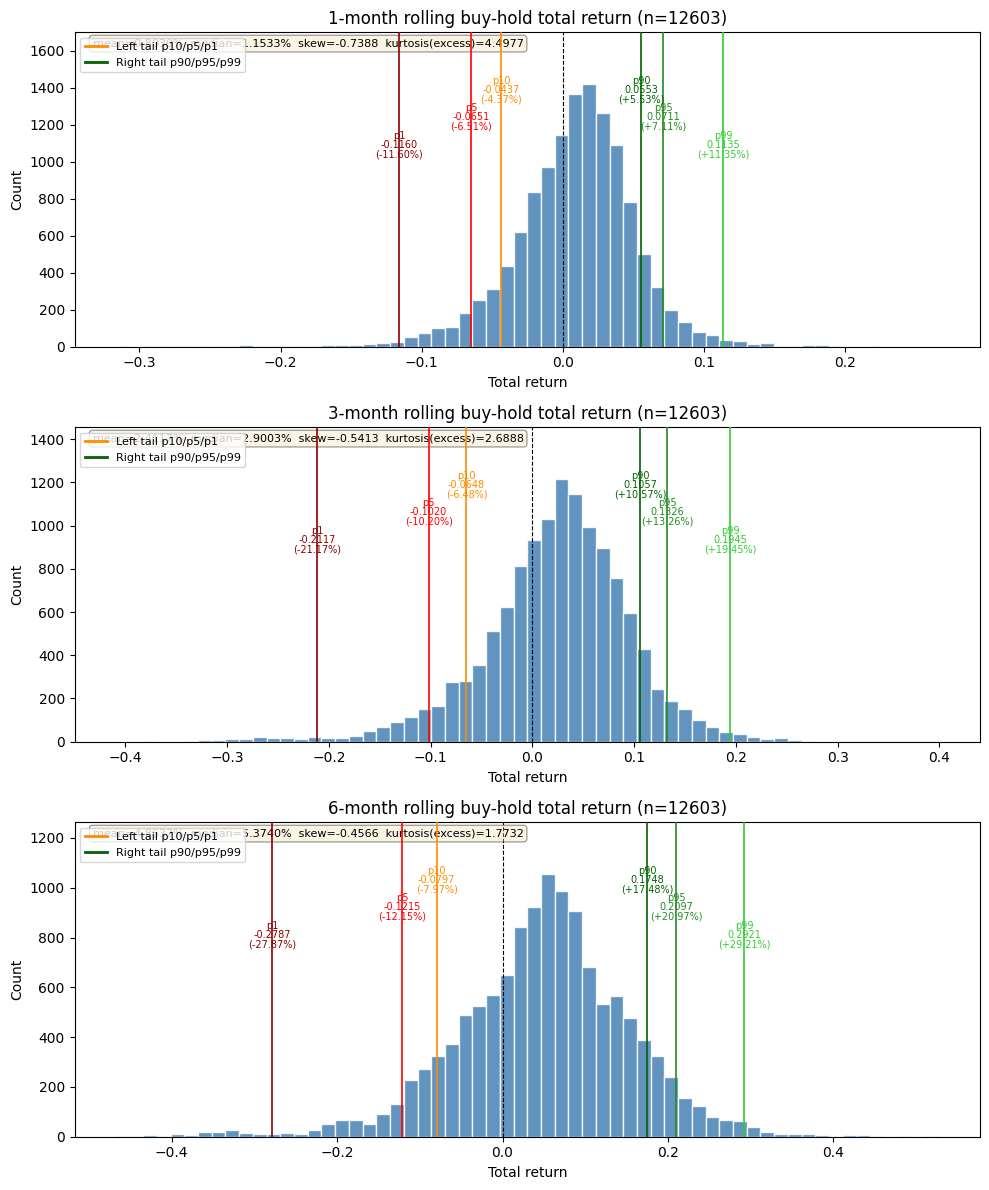

{'return_p1': -0.11601267569427189,
 'return_p5': -0.06511738096189126,
 'return_p10': -0.04369981368910305,
 'loss_magnitude_p99': 0.11601267569427189,
 'loss_magnitude_p95': 0.06511738096189126,
 'loss_magnitude_p90': 0.04369981368910305,
 'return_p90': 0.05529902757968329,
 'return_p95': 0.0711111161988406,
 'return_p99': 0.11346280066652063,
 'gain_magnitude_p90': 0.05529902757968329,
 'gain_magnitude_p95': 0.0711111161988406,
 'gain_magnitude_p99': 0.11346280066652063}

In [13]:
from spx_rolling_buyhold import analyze_spx_rolling, load_spx, rolling_calendar_month_returns, tail_loss_percentiles

out = analyze_spx_rolling()
out[1]["full_moments"]
#out[1]["right_tail_moments"]
out[1]["tail_metrics"]

### peak-to-trough drawdown

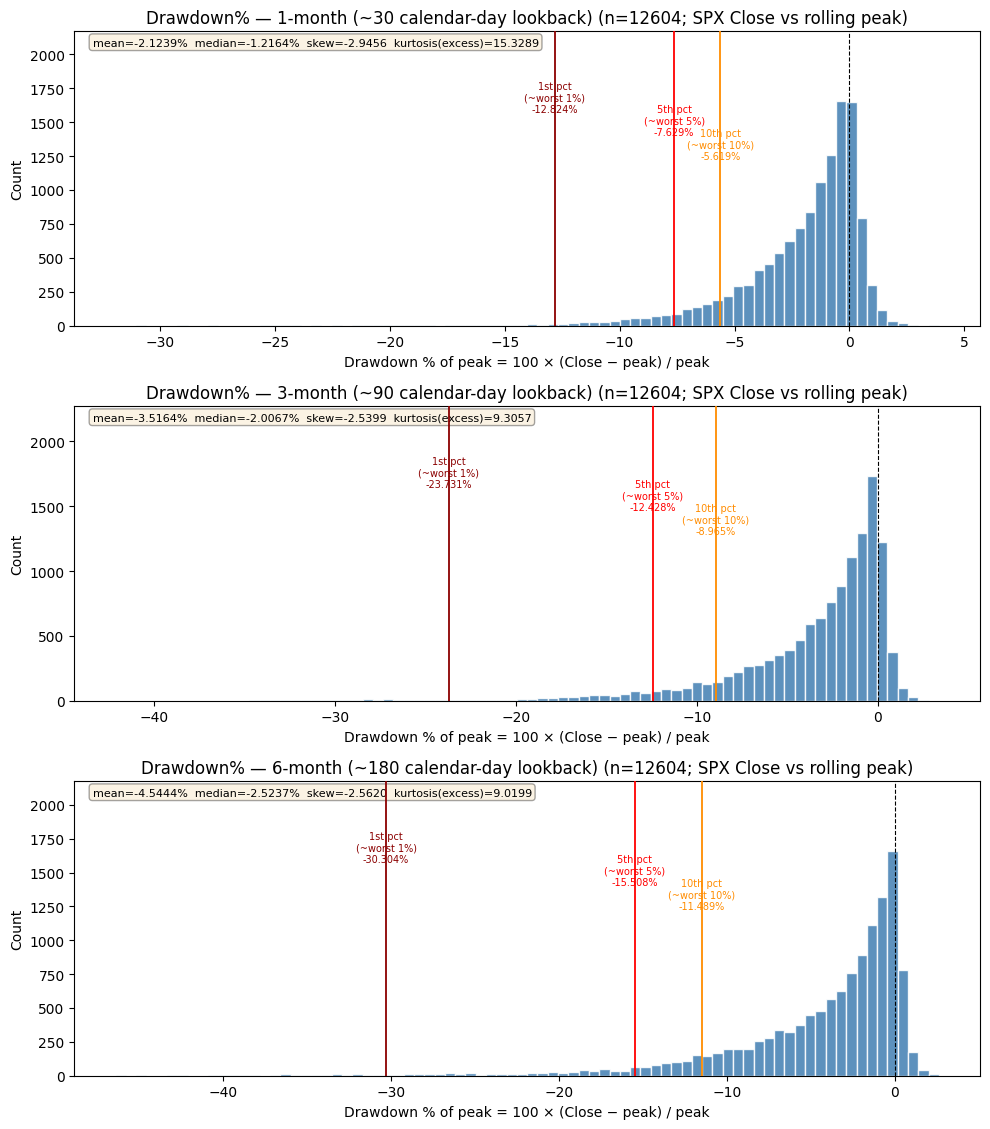

Worst-case tail: 1st / 5th / 10th pct of drawdown/peak (more negative = worse); ~99% / 95% / 90% of days are less severe. Moments on same series (fraction; ×100 = %).
  1M (~30d): n=12604  p1=-12.824%  p5=-7.629%  p10=-5.619%  |  mean=-2.1239%  median=-1.2164%  skew=-2.9456  kurtosis(excess)=15.3289
  3M (~90d): n=12604  p1=-23.731%  p5=-12.428%  p10=-8.965%  |  mean=-3.5164%  median=-2.0067%  skew=-2.5399  kurtosis(excess)=9.3057
  6M (~180d): n=12604  p1=-30.304%  p5=-15.508%  p10=-11.489%  |  mean=-4.5444%  median=-2.5237%  skew=-2.5620  kurtosis(excess)=9.0199


In [1]:
%matplotlib inline

from spx_drawdown_severity import analyze_spx_drawdown_percentiles

# ~1M / 3M / 6M calendar-day rolling peak (30 / 90 / 180 days).
out = analyze_spx_drawdown_percentiles(periods=(30, 90, 180))

## Default parametric simulation draws fresh z_t 


=== 1 calendar month (simulated pooled) ===
Observations: 1006600
  mean=0.007937  median=0.008453  skew=89.9773  kurtosis(excess)=27735.6266
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.050735
    p5: -0.073733
    p1: -0.138449
  Right tail (p90/p95/p99):
    p90: 0.063757
    p95: 0.083297
    p99: 0.139605

=== 3 calendar months (simulated pooled) ===
Observations: 1006600
  mean=0.022253  median=0.024056  skew=38.2037  kurtosis(excess)=8803.9287
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.074653
    p5: -0.114710
    p1: -0.226924
  Right tail (p90/p95/p99):
    p90: 0.115456
    p95: 0.144683
    p99: 0.217365

=== 6 calendar months (simulated pooled) ===
Observations: 1006600
  mean=0.044358  median=0.046318  skew=16.7868  kurtosis(excess)=2965.4297
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.089753
    p5: -0.137038
    p1: -0.305586
  Right tail (p90/p95/p99):
    p90

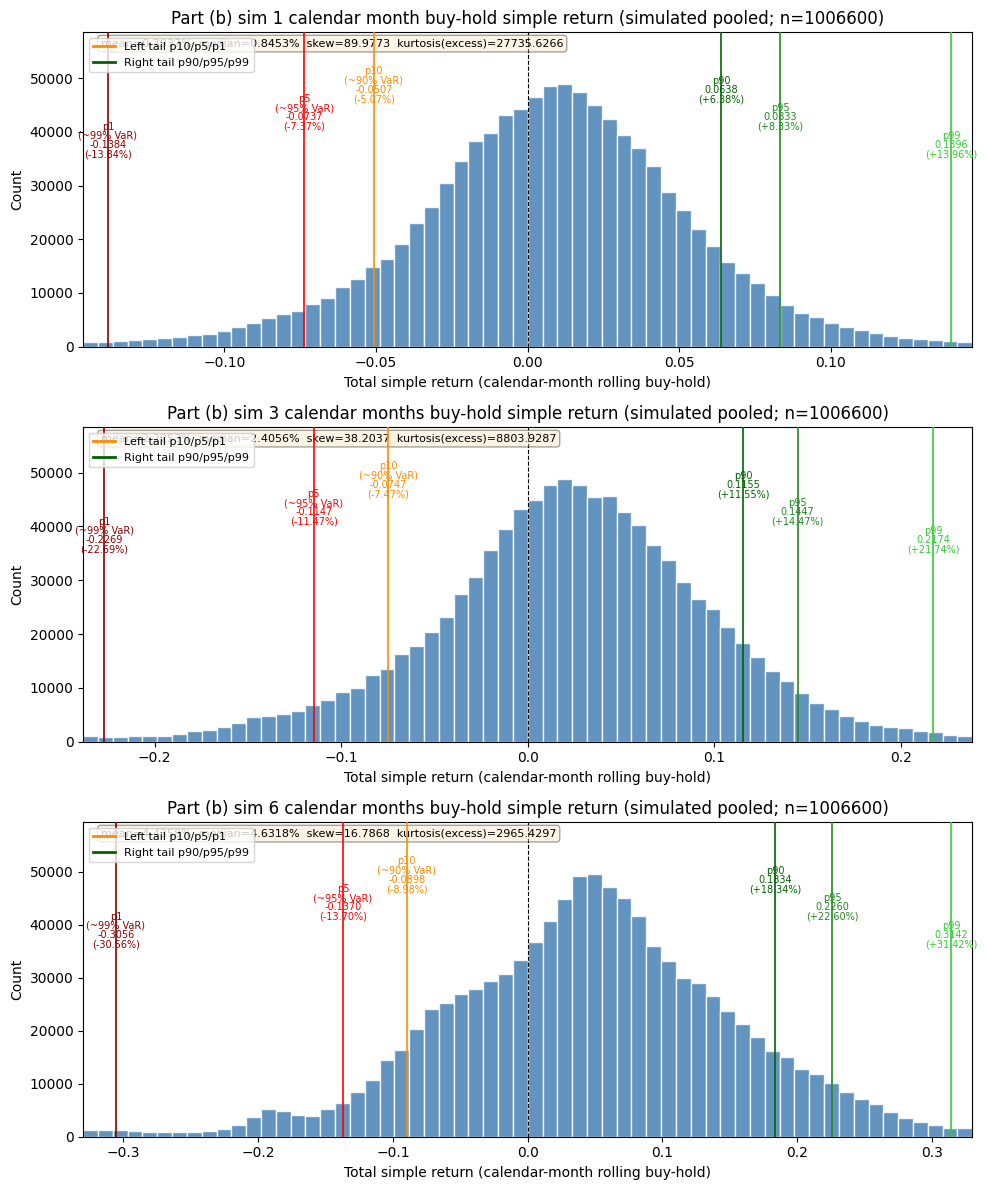

{'return_p1': -0.3055860123834947,
 'return_p5': -0.13703818158310271,
 'return_p10': -0.08975346279802149,
 'loss_magnitude_p99': 0.3055860123834947,
 'loss_magnitude_p95': 0.13703818158310271,
 'loss_magnitude_p90': 0.08975346279802149,
 'return_p90': 0.18342307144101924,
 'return_p95': 0.2259796544197957,
 'return_p99': 0.3141642863026681,
 'gain_magnitude_p90': 0.18342307144101924,
 'gain_magnitude_p95': 0.2259796544197957,
 'gain_magnitude_p99': 0.3141642863026681}

In [15]:
from spx_trading_day_buyhold import analyze_partb2_simulated_calendar_month_buyhold

cal_bh = analyze_partb2_simulated_calendar_month_buyhold(
    monthly_early, daily_full, garch,
    n_paths=100,
    seed=42,
    show_plots=True,
)
cal_bh[1]["tail_metrics"]
cal_bh[3]["tail_metrics"]
cal_bh[6]["tail_metrics"]

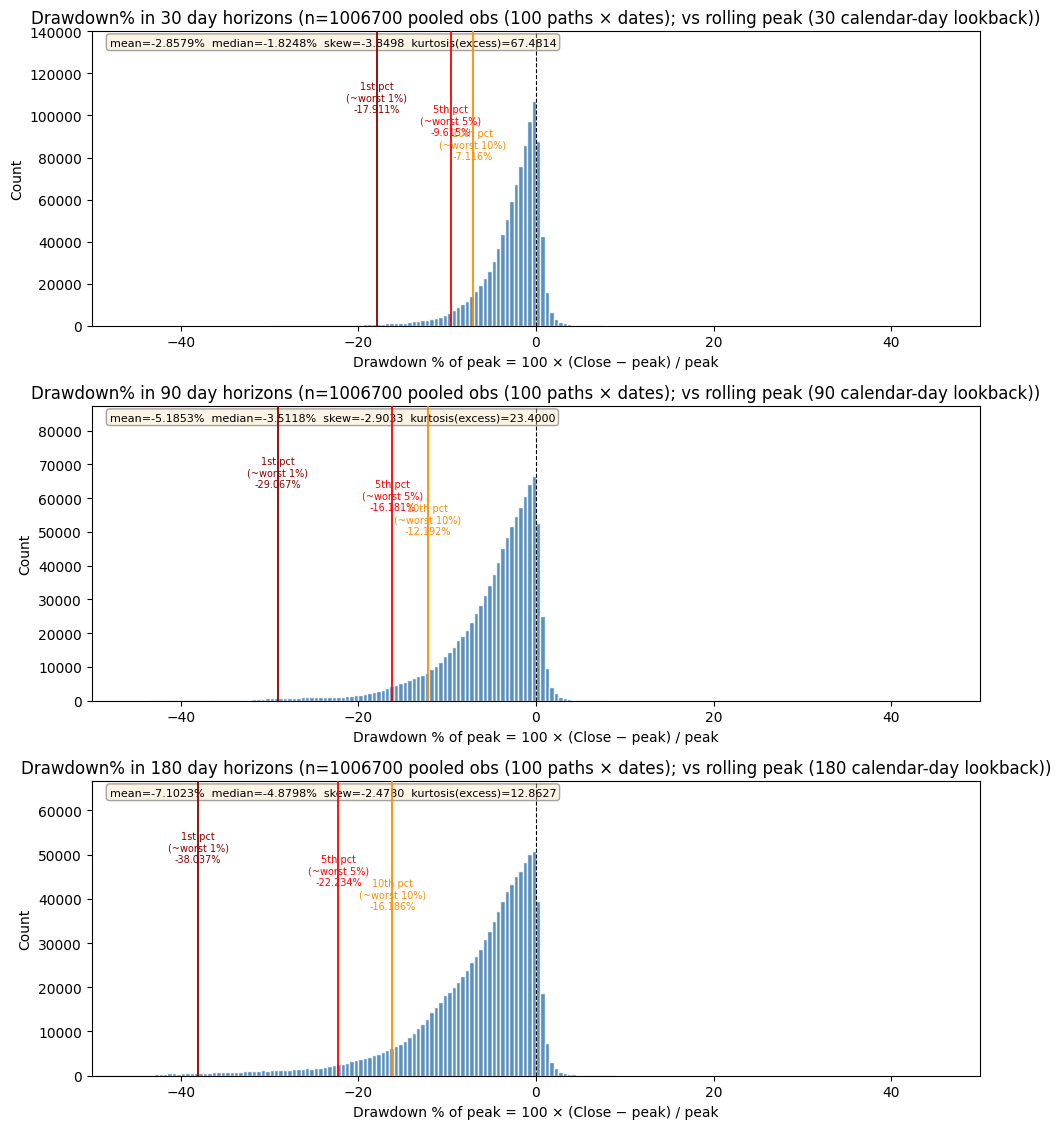

Part (b) sim — pool='pooled': same rolling-peak fractional DD as Part (a); 1st/5th/10th pct = left tail (more negative = worse).
  30-day: n=1006700  p1=-17.911%  p5=-9.615%  p10=-7.116%  |  mean=-2.8579%  median=-1.8248%  skew=-3.8498  kurtosis(excess)=67.4814
  90-day: n=1006700  p1=-29.067%  p5=-16.181%  p10=-12.192%  |  mean=-5.1853%  median=-3.5118%  skew=-2.9033  kurtosis(excess)=23.4000
  180-day: n=1006700  p1=-38.037%  p5=-22.234%  p10=-16.186%  |  mean=-7.1023%  median=-4.8798%  skew=-2.4780  kurtosis(excess)=12.8627


In [16]:
from spx_drawdown_severity import analyze_partb2_simulated_drawdown_percentiles

dd_sim = analyze_partb2_simulated_drawdown_percentiles(
    monthly_early,
    daily_full,
    garch,
    n_paths=100,
    seed=42,
    periods_calendar_days=(30, 90, 180),  # ~1m / 3m / 6m calendar days
    pool="pooled",  # or "mean_path"
    show_plots=True,
)

## Testing simulated paths from the above application

In [17]:
from calendar import month_name

from partb_sim import (
    list_allowed_bridge_months,
    month_paths_to_long_df,
    simulate_partb2_month_paths,
)

# Every allowed (year, month) is a calendar month whose **last trading day** is a
# row in `monthly_early` and is the **end** of a bridge segment (previous
# month-end close → this month-end close).
ALLOWED_YM = list_allowed_bridge_months(monthly_early, daily_full)
# set(ALLOWED_YM)  # uncomment to inspect


def year_month_from_name(year: int, name: str) -> tuple[int, int]:
    """Map e.g. ``year_month_from_name(2020, 'March')`` → ``(2020, 3)``."""
    n = name.strip().lower()
    for i in range(1, 13):
        if month_name[i].lower() == n:
            return year, i
    raise ValueError(f"unknown month name: {name!r}; use January … December")


# --- choose a month that exists in `monthly_early` as an interval end ---
YEAR, MONTH = 1996, 3  # or: YEAR, MONTH = year_month_from_name(1996, "March")

month_mc = simulate_partb2_month_paths(
    monthly_early,
    daily_full,
    garch,
    year=YEAR,
    month=MONTH,
    n_paths=30,
    seed=42,
    innovations="parametric",  # or "bootstrap" (GARCH 1,1 only)
)

# Sanity: path starts at previous month-end Close, ends at this month-end Close
assert abs(month_mc["prices_paths"][:, 0] - month_mc["close_start"]).max() < 1e-9
assert abs(month_mc["prices_paths"][:, -1] - month_mc["close_end"]).max() < 1e-6

pd.DataFrame(
    {
        "date_start": [month_mc["date_start"]],
        "date_end": [month_mc["date_end"]],
        "close_start": [month_mc["close_start"]],
        "close_end": [month_mc["close_end"]],
        "n_days": [month_mc["n_trading_days"]],
        "max_abs_end_error": [month_mc["max_abs_end_error"]],
    }
)

# Long format: one row per (path, trading day) for charts
paths_long = month_paths_to_long_df(month_mc)
paths_long.head(12)


,Date,path_id,Close_sim,row_kind
0,1996-02-29,0,640.430000,month_start_anchor
1,1996-03-01,0,636.945722,eod
2,1996-03-04,0,630.044451,eod
3,1996-03-05,0,639.277791,eod
4,1996-03-06,0,637.422044,eod
5,1996-03-07,0,606.539977,eod
6,1996-03-08,0,618.481232,eod
7,1996-03-11,0,636.826148,eod
8,1996-03-12,0,660.326651,eod
9,1996-03-13,0,660.926617,eod


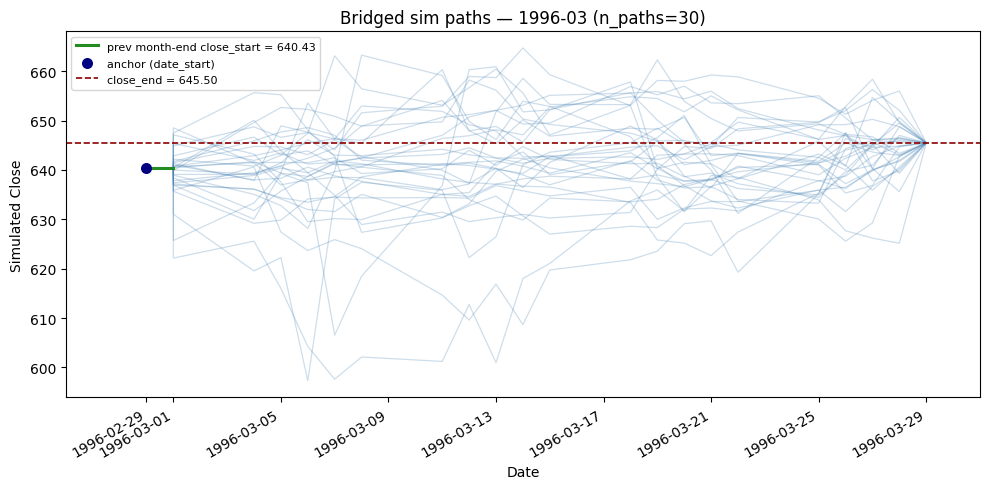

In [18]:
import matplotlib.pyplot as plt
from partb_sim import plot_partb2_month_mc_paths

# Previous month-end (date_start, close_start) is shared; first trading EOD varies by path unless first-day anchor is on.
fig, ax = plot_partb2_month_mc_paths(month_mc)
plt.show()

### Multi-year span validation (Part (b))

Run **after** `monthly_early`, `daily_full`, and `garch` exist (and ideally after `cal_bh` so you are in the same simulation mindset). **`simulate_partb2_year_span_batch`** slices `partb2_month_table` to several consecutive calendar years, simulates bridged paths, and checks that each path’s **month-end Close** matches the panel **`close_end`** (Part (b) anchors, unlike Part (c)’s in-month **mean** check). **`plot_partb_year_span_validation`** plots prices vs panel month-end levels plus a small error diagnostic.


start_year 2000 n slice months 36 all_ok True max_abs_error 5.6843418860808015e-12


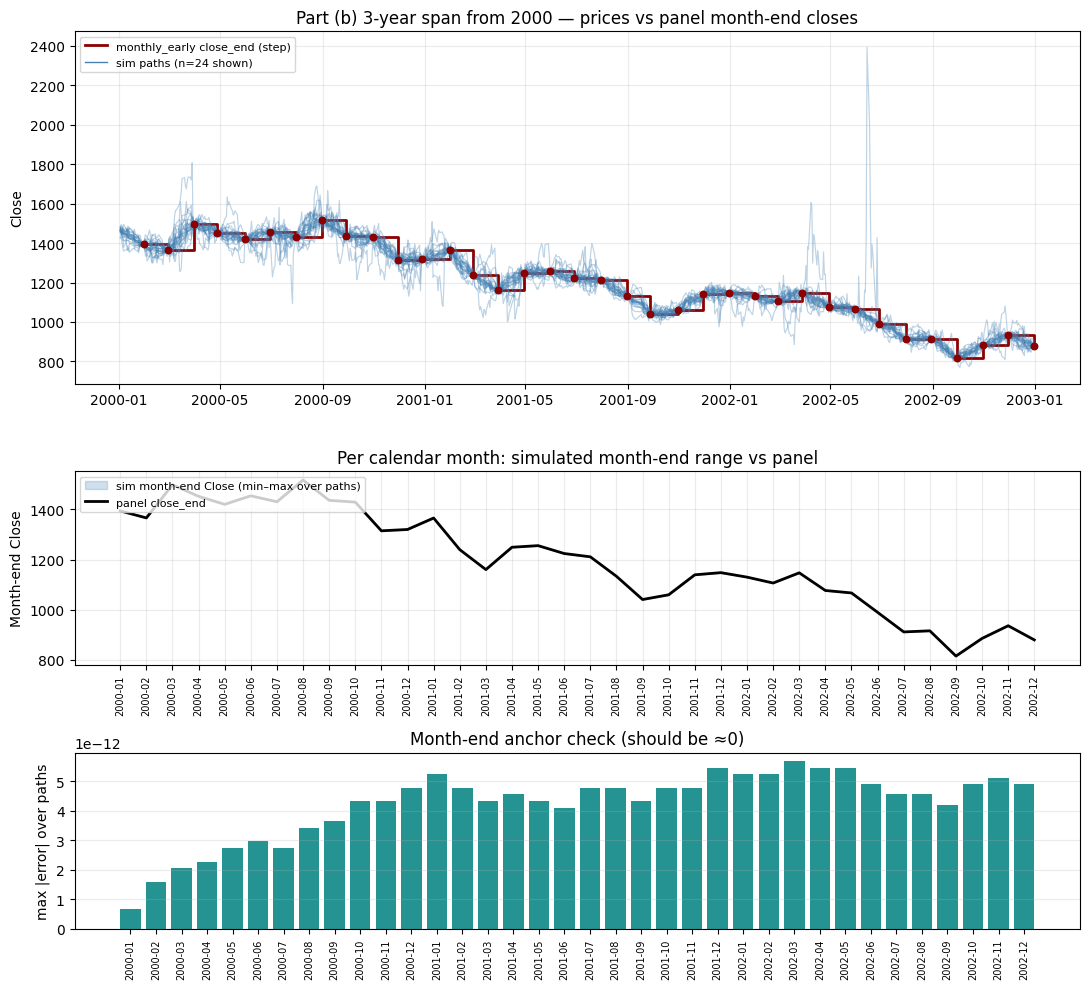

In [19]:
from partb_sim import plot_partb_year_span_validation, simulate_partb2_year_span_batch

# Defaults aligned with `cal_bh` above (parametric, seed=42, burn=500). Adjust if you change that cell.
YEAR_SPAN_BATCH = simulate_partb2_year_span_batch(
    monthly_early,
    daily_full,
    garch,
    n_paths=24,
    n_years=3,
    seed=42,
    burn=500,
    innovations="parametric",
    randomize_start_year=False,  # True → random feasible start year
    start_year=2000,  # optional: fix calendar start year
)
print(
    "start_year",
    YEAR_SPAN_BATCH["start_year"],
    "n slice months",
    len(YEAR_SPAN_BATCH["month_table_slice"]),
    "all_ok",
    YEAR_SPAN_BATCH["all_ok"],
    "max_abs_error",
    YEAR_SPAN_BATCH["max_abs_error"],
)
assert YEAR_SPAN_BATCH["all_ok"], "every month on every path should hit close_end"

fig, axes = plot_partb_year_span_validation(YEAR_SPAN_BATCH, max_paths_price=100)


## Pros quite comparable to the reference risk metrics
## Issues [CONS] of parametric selection: unrealistic returns are possible

In [20]:
import numpy as np

# Run after `cal_bh = analyze_partb2_simulated_calendar_month_buyhold(...)`.
# For historical SPX calendar plots, use `cal_hist` instead of `cal_bh` if the structure matches.
results = cal_bh
for hm in sorted(results.keys()):
    r = np.asarray(results[hm]["returns_array"], dtype=float)
    r = r[np.isfinite(r)]
    print(f"=== {hm} calendar month(s) (n={len(r):,}) ===")
    print(f"  full sample min / max: {r.min():.6f}  /  {r.max():.6f}")
    print(f"  as %: {r.min() * 100:.4f}%  …  {r.max() * 100:.4f}%")
    # Default plot window matches `xlim_symmetric_percentiles=(1, 99)` in analyze_partb2_simulated_calendar_month_buyhold
    lo1, hi99 = np.percentile(r, [1.0, 99.0])
    m = max(abs(float(lo1)), abs(float(hi99)))
    if m == 0.0:
        m = float(np.std(r) or 0.05)
    pad = max(0.05 * m, 1e-8)
    x_lo, x_hi = -m - pad, m + pad
    print(f"  default hist x-range (~symmetric p1–p99): [{x_lo:.6f}, {x_hi:.6f}]")


=== 1 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.966426  /  28.784944
  as %: -96.6426%  …  2878.4944%
  default hist x-range (~symmetric p1–p99): [-0.146585, 0.146585]
=== 3 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.966165  /  28.094482
  as %: -96.6165%  …  2809.4482%
  default hist x-range (~symmetric p1–p99): [-0.238270, 0.238270]
=== 6 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.965856  /  27.741929
  as %: -96.5856%  …  2774.1929%
  default hist x-range (~symmetric p1–p99): [-0.329873, 0.329873]


## Bootstrap method 

### Rolling Buyhold



=== 1 calendar month (simulated pooled) ===
Observations: 1006600
  mean=0.008623  median=0.008453  skew=209.1505  kurtosis(excess)=66374.0973
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.050725
    p5: -0.074024
    p1: -0.138919
  Right tail (p90/p95/p99):
    p90: 0.063691
    p95: 0.083247
    p99: 0.140060

=== 3 calendar months (simulated pooled) ===
Observations: 1006600
  mean=0.023010  median=0.024068  skew=172.4736  kurtosis(excess)=51417.1666
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.074879
    p5: -0.114401
    p1: -0.225748
  Right tail (p90/p95/p99):
    p90: 0.115235
    p95: 0.144942
    p99: 0.215559

=== 6 calendar months (simulated pooled) ===
Observations: 1006600
  mean=0.045136  median=0.046475  skew=133.2744  kurtosis(excess)=36617.0610
  Left tail (worst returns; p10/p5/p1) ~ 90%/95%/99% VaR confidence:
    p10: -0.089648
    p5: -0.137689
    p1: -0.305143
  Right tail (p90/p95/p99):
  

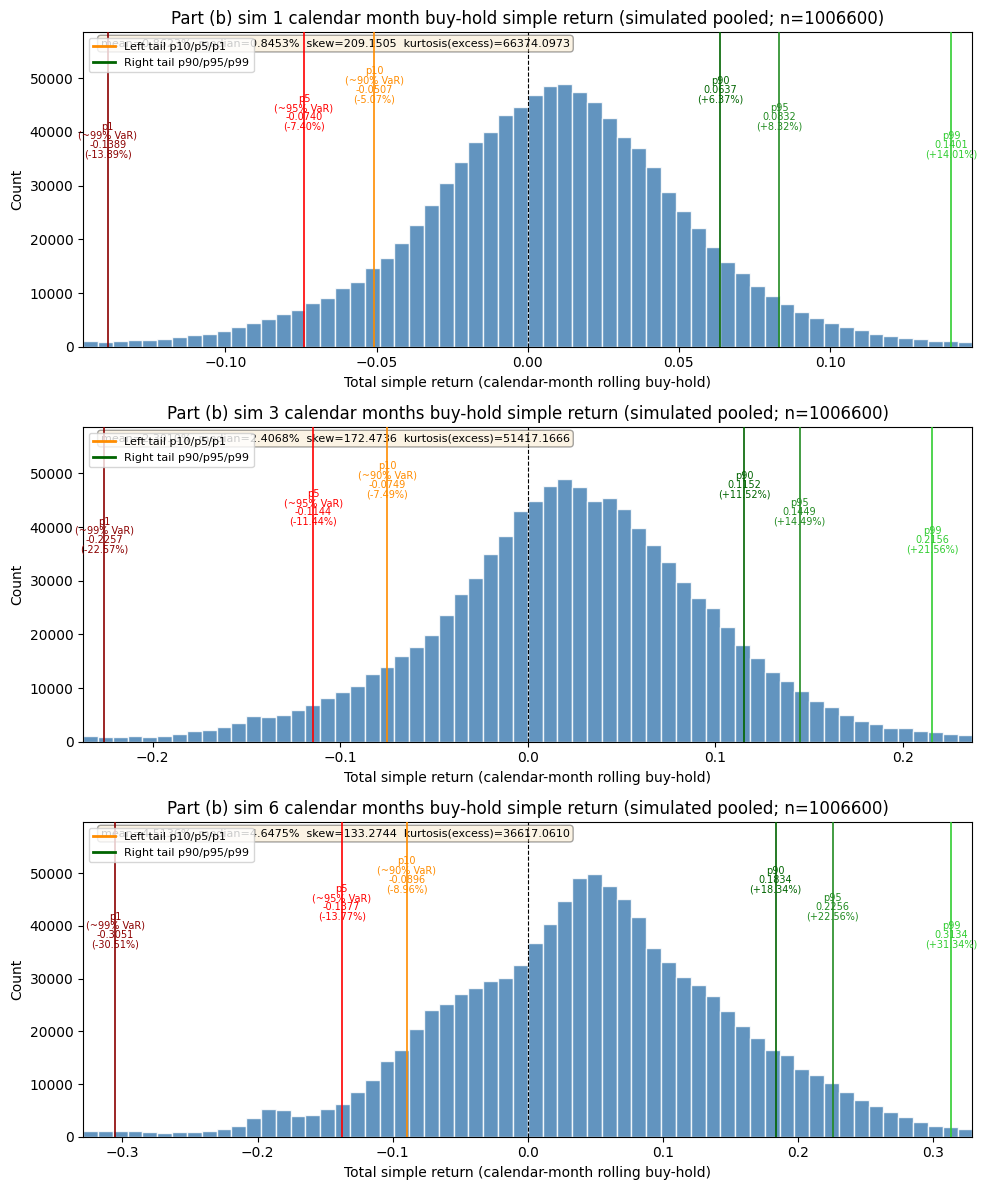

{'return_p1': -0.30514277708264353,
 'return_p5': -0.1376894984416622,
 'return_p10': -0.08964762279726393,
 'loss_magnitude_p99': 0.30514277708264353,
 'loss_magnitude_p95': 0.1376894984416622,
 'loss_magnitude_p90': 0.08964762279726393,
 'return_p90': 0.18340231702263002,
 'return_p95': 0.2255714924882298,
 'return_p99': 0.3133770132712563,
 'gain_magnitude_p90': 0.18340231702263002,
 'gain_magnitude_p95': 0.2255714924882298,
 'gain_magnitude_p99': 0.3133770132712563}

In [21]:
# Bootstrap innovations: resample in-sample standardized residuals (GARCH 1,1 only).
# See `partb_sim._draw_standardized_innovations` and module docstring.
from spx_trading_day_buyhold import analyze_partb2_simulated_calendar_month_buyhold

cal_bh_bootstrap = analyze_partb2_simulated_calendar_month_buyhold(
    monthly_early,
    daily_full,
    garch,
    n_paths=100,
    seed=42,
    innovations="bootstrap",
    show_plots=True,
)
cal_bh_bootstrap[1]["tail_metrics"]
cal_bh_bootstrap[3]["tail_metrics"]
cal_bh_bootstrap[6]["tail_metrics"]


## EVT on bootstrap-pooled calendar-month returns (Part b)

**Setup:** `innovations="bootstrap"` resamples **in-sample GARCH standardized residuals**; each bridged path yields calendar-month rolling **simple** returns, then all paths are **pooled** into `cal_bh_bootstrap[h]["returns_array"]`.

We set **Y = −R** (loss orientation) and run the same POT/GPD + hybrid quantiles as Part (a) `horizon_evt` so you can compare **empirical** `tail_metrics` with **GPD-smoothed** high quantiles.

**Caveat:** observations **overlap within paths** and paths share the same simulation design — the pooled sample is **not iid**. Treat the table as **descriptive / Monte Carlo** tail smoothing, not classical EVT asymptotics.


In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from parta_evt import evt_summary_pooled_simple_returns, fit_gpd_exceedances, gpd_qq_points

horizons = (1, 3, 6)
rows = [evt_summary_pooled_simple_returns(cal_bh_bootstrap[h]["returns_array"], horizon_m=h) for h in horizons]
horizon_evt_bootstrap = pd.DataFrame(rows)
horizon_evt_bootstrap


,horizon_m,n,empirical_return_p1,empirical_loss_mag_1pct_tail,GPD_u,GPD_xi,n_exceed,hybrid_q99_loss_Y,hybrid_q99.5_loss_Y
0,1,1006600,-0.138919,0.138919,0.058266,0.216225,80528,0.138732,0.174659
1,3,1006600,-0.225748,0.225748,0.087395,0.069745,80528,0.213787,0.260158
2,6,1006600,-0.305143,0.305143,0.103569,0.048028,80528,0.275615,0.336889


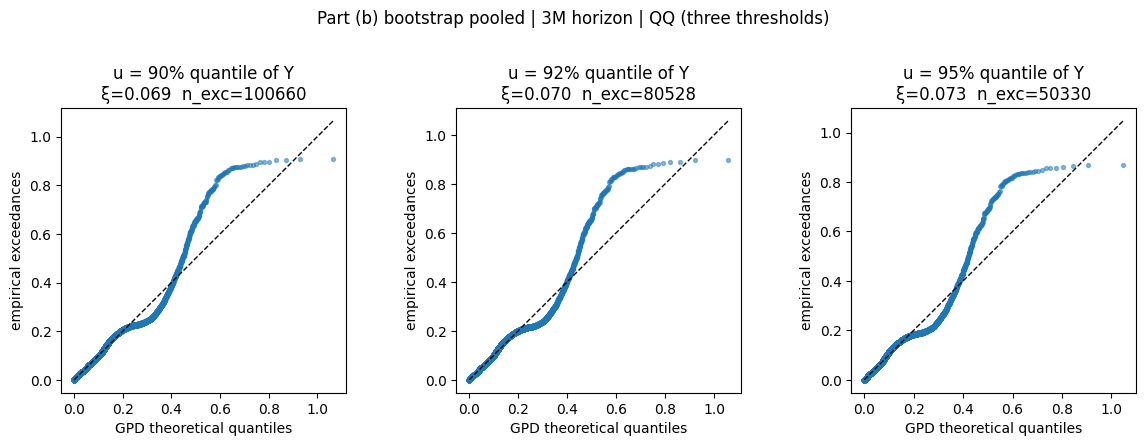

In [23]:
# QQ diagnostic: 3-calendar-month horizon — three POT thresholds (quantiles of Y = −R)
h_qq = 3
r = np.asarray(cal_bh_bootstrap[h_qq]["returns_array"], dtype=float)
r = r[np.isfinite(r)]
Y = -r
threshold_qs = (0.90, 0.92, 0.95)
fig, axes = plt.subplots(1, len(threshold_qs), figsize=(4 * len(threshold_qs), 4))
for ax, q in zip(np.atleast_1d(axes), threshold_qs):
    u_star = float(np.quantile(Y, q))
    fit = fit_gpd_exceedances(Y, u_star, min_exceedances=80)
    w = Y[Y > u_star] - u_star
    w = w[w > 0]
    emp_qq, theo_qq = gpd_qq_points(w, fit.xi, fit.sigma)
    ax.scatter(theo_qq, emp_qq, s=8, alpha=0.5)
    lim = float(max(emp_qq.max(), theo_qq.max()))
    ax.plot([0, lim], [0, lim], "k--", lw=1)
    ax.set_xlabel("GPD theoretical quantiles")
    ax.set_ylabel("empirical exceedances")
    ax.set_title(
        f"u = {int(q * 100)}% quantile of Y\nξ={fit.xi:.3f}  n_exc={fit.n_exceedances}"
    )
    ax.set_aspect("equal", adjustable="box")
fig.suptitle("Part (b) bootstrap pooled | 3M horizon | QQ (three thresholds)", y=1.06)
plt.tight_layout()
plt.show()


### Peak-to-Trough Drawdown

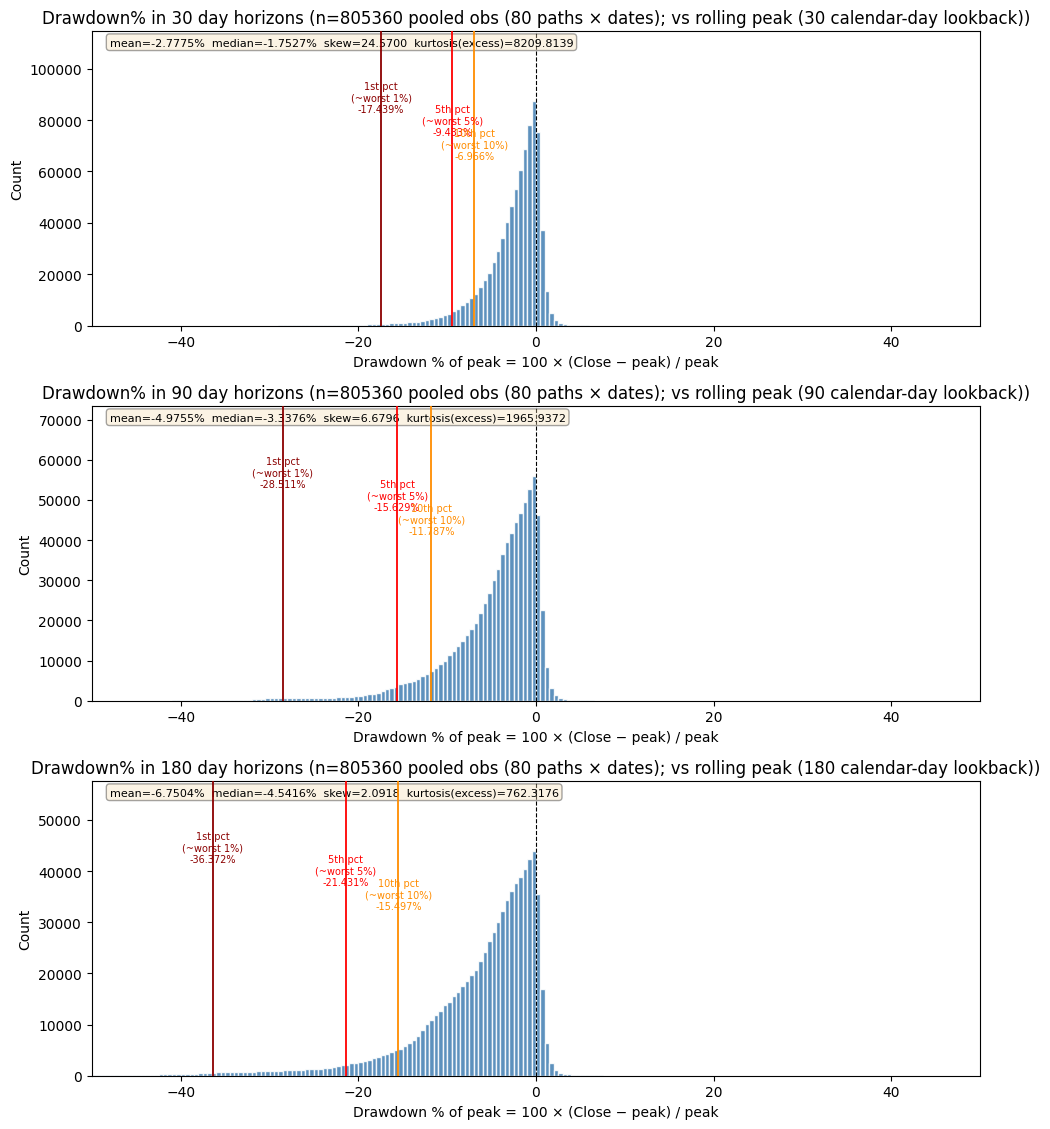

Part (b) sim — pool='pooled': same rolling-peak fractional DD as Part (a); 1st/5th/10th pct = left tail (more negative = worse).
  30-day: n=805360  p1=-17.439%  p5=-9.433%  p10=-6.966%  |  mean=-2.7775%  median=-1.7527%  skew=24.5700  kurtosis(excess)=8209.8139
  90-day: n=805360  p1=-28.511%  p5=-15.629%  p10=-11.787%  |  mean=-4.9755%  median=-3.3376%  skew=6.6796  kurtosis(excess)=1965.9372
  180-day: n=805360  p1=-36.372%  p5=-21.431%  p10=-15.497%  |  mean=-6.7504%  median=-4.5416%  skew=2.0918  kurtosis(excess)=762.3176


In [24]:
from spx_drawdown_severity import analyze_partb2_simulated_drawdown_percentiles

dd_sim = analyze_partb2_simulated_drawdown_percentiles(
    monthly_early,
    daily_full,
    garch,
    n_paths=80,
    seed=42,
    periods_calendar_days=(30, 90, 180),  # ~1m / 3m / 6m calendar days
    pool="pooled",  # or "mean_path"
    innovations="bootstrap",
    show_plots=True,
)

## Testing simulated paths from the bootstrap method application

In [25]:
from calendar import month_name

from partb_sim import (
    list_allowed_bridge_months,
    month_paths_to_long_df,
    simulate_partb2_month_paths,
)

# Every allowed (year, month) is a calendar month whose **last trading day** is a
# row in `monthly_early` and is the **end** of a bridge segment (previous
# month-end close → this month-end close).
ALLOWED_YM = list_allowed_bridge_months(monthly_early, daily_full)
# set(ALLOWED_YM)  # uncomment to inspect


def year_month_from_name(year: int, name: str) -> tuple[int, int]:
    """Map e.g. ``year_month_from_name(2020, 'March')`` → ``(2020, 3)``."""
    n = name.strip().lower()
    for i in range(1, 13):
        if month_name[i].lower() == n:
            return year, i
    raise ValueError(f"unknown month name: {name!r}; use January … December")


# --- choose a month that exists in `monthly_early` as an interval end ---
YEAR, MONTH = 1996, 3  # or: YEAR, MONTH = year_month_from_name(1996, "March")

month_mc = simulate_partb2_month_paths(
    monthly_early,
    daily_full,
    garch,
    year=YEAR,
    month=MONTH,
    n_paths=30,
    seed=42,
    innovations="bootstrap",  # or "bootstrap" (GARCH 1,1 only)
)

# Sanity: path starts at previous month-end Close, ends at this month-end Close
assert abs(month_mc["prices_paths"][:, 0] - month_mc["close_start"]).max() < 1e-9
assert abs(month_mc["prices_paths"][:, -1] - month_mc["close_end"]).max() < 1e-6

pd.DataFrame(
    {
        "date_start": [month_mc["date_start"]],
        "date_end": [month_mc["date_end"]],
        "close_start": [month_mc["close_start"]],
        "close_end": [month_mc["close_end"]],
        "n_days": [month_mc["n_trading_days"]],
        "max_abs_end_error": [month_mc["max_abs_end_error"]],
    }
)

# Long format: one row per (path, trading day) for charts
paths = month_paths_to_long_df(month_mc)
paths.head(12)


,Date,path_id,Close_sim,row_kind
0,1996-02-29,0,640.430000,month_start_anchor
1,1996-03-01,0,644.791724,eod
2,1996-03-04,0,641.216246,eod
3,1996-03-05,0,642.011660,eod
4,1996-03-06,0,641.381655,eod
5,1996-03-07,0,643.097942,eod
6,1996-03-08,0,642.271248,eod
7,1996-03-11,0,640.459921,eod
8,1996-03-12,0,636.217857,eod
9,1996-03-13,0,636.338277,eod


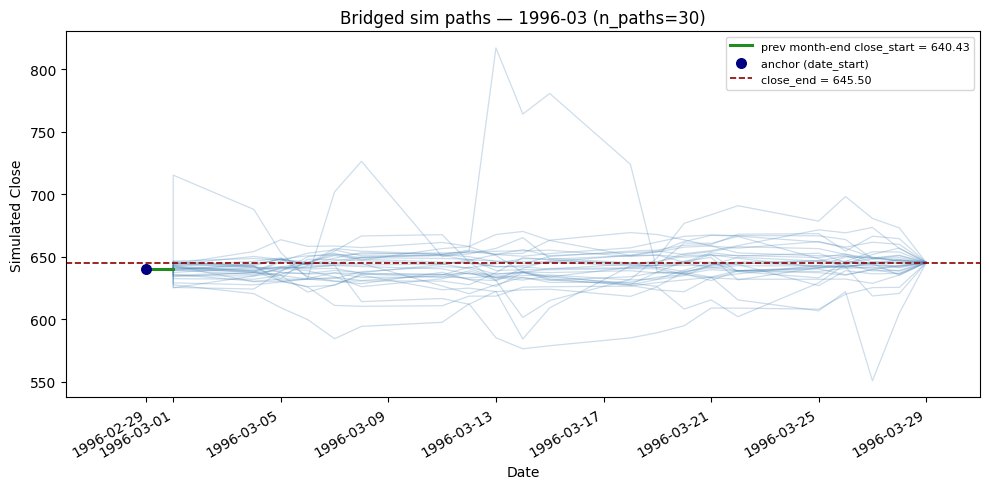

In [26]:
import matplotlib.pyplot as plt
from partb_sim import plot_partb2_month_mc_paths

# Same anchoring rule for any target month: shared prev month-end; first trading EOD can differ by path.
fig, ax = plot_partb2_month_mc_paths(month_mc)
plt.show()

### Multi-year span validation (Part (b))

Run **after** `monthly_early`, `daily_full`, and `garch` exist (and ideally after `cal_bh` so you are in the same simulation mindset). **`simulate_partb2_year_span_batch`** slices `partb2_month_table` to several consecutive calendar years, simulates bridged paths, and checks that each path’s **month-end Close** matches the panel **`close_end`** (Part (b) anchors, unlike Part (c)’s in-month **mean** check). **`plot_partb_year_span_validation`** plots prices vs panel month-end levels plus a small error diagnostic.


start_year 2000 n slice months 36 all_ok True max_abs_error 5.229594535194337e-12


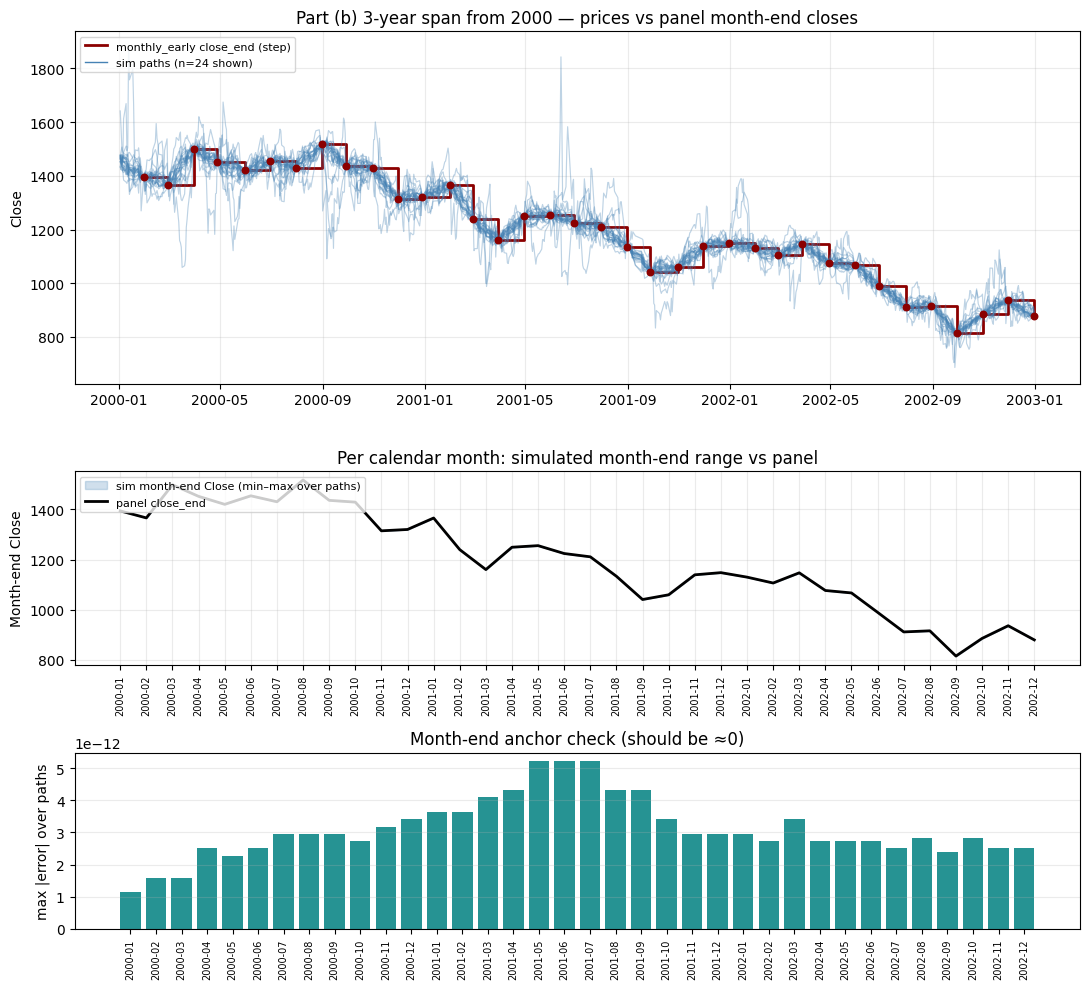

In [27]:
from partb_sim import plot_partb_year_span_validation, simulate_partb2_year_span_batch

# Defaults aligned with `cal_bh` above (parametric, seed=42, burn=500). Adjust if you change that cell.
YEAR_SPAN_BATCH = simulate_partb2_year_span_batch(
    monthly_early,
    daily_full,
    garch,
    n_paths=24,
    n_years=3,
    seed=42,
    burn=500,
    innovations="bootstrap",
    randomize_start_year=False,  # True → random feasible start year
    start_year=2000,  # optional: fix calendar start year
)
print(
    "start_year",
    YEAR_SPAN_BATCH["start_year"],
    "n slice months",
    len(YEAR_SPAN_BATCH["month_table_slice"]),
    "all_ok",
    YEAR_SPAN_BATCH["all_ok"],
    "max_abs_error",
    YEAR_SPAN_BATCH["max_abs_error"],
)
assert YEAR_SPAN_BATCH["all_ok"], "every month on every path should hit close_end"

fig, axes = plot_partb_year_span_validation(YEAR_SPAN_BATCH, max_paths_price=100)


## Pros quite comparable to the reference risk metrics
## Issues [CONS] of bootstrap method 

In [28]:
import numpy as np

# Run after `cal_bh = analyze_partb2_simulated_calendar_month_buyhold(...)`.
# For historical SPX calendar plots, use `cal_hist` instead of `cal_bh` if the structure matches.
results = cal_bh_bootstrap
for hm in sorted(results.keys()):
    r = np.asarray(results[hm]["returns_array"], dtype=float)
    r = r[np.isfinite(r)]
    print(f"=== {hm} calendar month(s) (n={len(r):,}) ===")
    print(f"  full sample min / max: {r.min():.6f}  /  {r.max():.6f}")
    print(f"  as %: {r.min() * 100:.4f}%  …  {r.max() * 100:.4f}%")
    # Default plot window matches `xlim_symmetric_percentiles=(1, 99)` in analyze_partb2_simulated_calendar_month_buyhold
    lo1, hi99 = np.percentile(r, [1.0, 99.0])
    m = max(abs(float(lo1)), abs(float(hi99)))
    if m == 0.0:
        m = float(np.std(r) or 0.05)
    pad = max(0.05 * m, 1e-8)
    x_lo, x_hi = -m - pad, m + pad
    print(f"  default hist x-range (~symmetric p1–p99): [{x_lo:.6f}, {x_hi:.6f}]")

=== 1 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.985640  /  74.406765
  as %: -98.5640%  …  7440.6765%
  default hist x-range (~symmetric p1–p99): [-0.147063, 0.147063]
=== 3 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.984569  /  76.783763
  as %: -98.4569%  …  7678.3763%
  default hist x-range (~symmetric p1–p99): [-0.237035, 0.237035]
=== 6 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.985994  /  77.525339
  as %: -98.5994%  …  7752.5339%
  default hist x-range (~symmetric p1–p99): [-0.329046, 0.329046]


### Pooled min/max rolling calendar returns — **`CAL_ROLL_EXTREMA`**

**Execution order:** run the **next code cell only after** `analyze_partb2_simulated_calendar_month_buyhold` has produced `cal_bh` and/or `cal_bh_bootstrap`. Set `CAL_EXTREMA_MODE` to `"parametric"` or `"bootstrap"`. Keep **`_CAL_BH_KW`** aligned with that `analyze_*` call (`seed`, `n_paths`, `burn`, `innovations`, `horizons_months`, and **`use_first_trading_day_close_anchor`** if you use it).


In [29]:
# Pooled min/max rolling calendar windows + daily Close paths → CAL_ROLL_EXTREMA
CAL_EXTREMA_MODE = "parametric"  # "parametric" → needs cal_bh | "bootstrap" → needs cal_bh_bootstrap

import numpy as np
from partb_sim import (
    partb2_pool_calendar_month_returns_detailed,
    simulate_partb2_path_at_pool_index,
    partb_close_series_for_calendar_window,
)

if CAL_EXTREMA_MODE == "parametric":
    _CAL_BH_KW = dict(
        horizons_months=(1, 3, 6),
        n_paths=100,
        seed=42,
        burn=500,
        innovations="parametric",
        use_first_trading_day_close_anchor=False,
    )
    results = cal_bh
elif CAL_EXTREMA_MODE == "bootstrap":
    _CAL_BH_KW = dict(
        horizons_months=(1, 3, 6),
        n_paths=100,
        seed=42,
        burn=500,
        innovations="bootstrap",
        use_first_trading_day_close_anchor=False,
    )
    results = cal_bh_bootstrap
else:
    raise ValueError(f"CAL_EXTREMA_MODE={CAL_EXTREMA_MODE!r}; use 'parametric' or 'bootstrap'")

cal_returns_detail = partb2_pool_calendar_month_returns_detailed(
    monthly_early, daily_full, garch, **_CAL_BH_KW
)
CAL_ROLL_EXTREMA = {}

for hm in sorted(results.keys()):
    r = np.asarray(results[hm]["returns_array"], dtype=float)
    r = r[np.isfinite(r)]
    print(f"=== {hm} calendar month(s) (n={len(r):,}) ===")
    print(f"  full sample min / max: {r.min():.6f}  /  {r.max():.6f}")
    print(f"  as %: {r.min() * 100:.4f}%  …  {r.max() * 100:.4f}%")
    lo1, hi99 = np.percentile(r, [1.0, 99.0])
    m = max(abs(float(lo1)), abs(float(hi99)))
    if m == 0.0:
        m = float(np.std(r) or 0.05)
    pad = max(0.05 * m, 1e-8)
    x_lo, x_hi = -m - pad, m + pad
    print(f"  default hist x-range (~symmetric p1–p99): [{x_lo:.6f}, {x_hi:.6f}]")

    dfp = cal_returns_detail[hm]
    r_worst = dfp.loc[dfp["return"].idxmin()]
    r_best = dfp.loc[dfp["return"].idxmax()]
    print("  --- min return window (path_id, dates, prices) ---")
    print(r_worst[["path_id", "start_date", "end_date", "start_price", "end_price", "return"]].to_string())
    print("  --- max return window ---")
    print(r_best[["path_id", "start_date", "end_date", "start_price", "end_price", "return"]].to_string())

    p_lo = simulate_partb2_path_at_pool_index(
        monthly_early,
        daily_full,
        garch,
        path_index=int(r_worst["path_id"]),
        n_paths=_CAL_BH_KW["n_paths"],
        seed=_CAL_BH_KW["seed"],
        burn=_CAL_BH_KW["burn"],
        innovations=_CAL_BH_KW["innovations"],
        use_first_trading_day_close_anchor=_CAL_BH_KW["use_first_trading_day_close_anchor"],
    )
    s_lo = partb_close_series_for_calendar_window(p_lo, r_worst["start_date"], r_worst["end_date"])
    p_hi = simulate_partb2_path_at_pool_index(
        monthly_early,
        daily_full,
        garch,
        path_index=int(r_best["path_id"]),
        n_paths=_CAL_BH_KW["n_paths"],
        seed=_CAL_BH_KW["seed"],
        burn=_CAL_BH_KW["burn"],
        innovations=_CAL_BH_KW["innovations"],
        use_first_trading_day_close_anchor=_CAL_BH_KW["use_first_trading_day_close_anchor"],
    )
    s_hi = partb_close_series_for_calendar_window(p_hi, r_best["start_date"], r_best["end_date"])
    CAL_ROLL_EXTREMA[hm] = {
        "row_min": r_worst,
        "row_max": r_best,
        "series_min": s_lo,
        "series_max": s_hi,
    }


=== 1 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.966426  /  28.784944
  as %: -96.6426%  …  2878.4944%
  default hist x-range (~symmetric p1–p99): [-0.146585, 0.146585]
  --- min return window (path_id, dates, prices) ---
path_id                         21
start_date     1983-09-15 00:00:00
end_date       1983-10-14 00:00:00
start_price             165.253268
end_price                 5.548199
return                   -0.966426
  --- max return window ---
path_id                         21
start_date     1983-10-14 00:00:00
end_date       1983-11-14 00:00:00
start_price               5.548199
end_price               165.252797
return                   28.784944
=== 3 calendar month(s) (n=1,006,600) ===
  full sample min / max: -0.966165  /  28.094482
  as %: -96.6165%  …  2809.4482%
  default hist x-range (~symmetric p1–p99): [-0.238270, 0.238270]
  --- min return window (path_id, dates, prices) ---
path_id                         21
start_date     1983-07-15 00:00